# Data pipeline validation

Consolidates and proves the three safety guarantees the generator depends on
before any image gets synthesized:

1. **Hidden-test leakage guard** - no generation lineage may touch TEST data.
2. **Figure-furniture exclusion** - no patch may be built from a scale bar,
   panel letter, or caption burned into an EMPS image.
3. **Modality-claim guard** - no EMPS-derived claim may say "SEM" (EMPS mixes
   unlabelled SEM+TEM; only RODARE earns that word).

Each guarantee below is demonstrated, not just asserted: a deliberately
contaminated input is fed to the check, and we confirm it actually fails.


## 1. Source split and grouping

Built once in `source_safe_split_and_loader.ipynb` (see that notebook for how
the split is constructed). Here we only load the existing manifest, since
every later section depends on it - rebuilding it again here would duplicate
that notebook's responsibility.

In [1]:
import sys, os, json
sys.path.append(os.path.join("..", "..", "src"))

manifest_path = os.path.join("..", "..", "configs", "experiments", "source_split_v1.json")
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(f"train:      {len(manifest['train_ids']):3d} images / {len(manifest['train_sources']):3d} DOI groups")
print(f"validation: {len(manifest['validation_ids']):3d} images / {len(manifest['validation_sources']):3d} DOI groups")
print(f"test:       {len(manifest['test_ids']):3d} images / {len(manifest['test_sources']):3d} DOI groups")
print(f"group_of covers {len(manifest['group_of'])} images (image_id -> DOI)")


train:      310 images / 210 DOI groups
validation:  56 images /  37 DOI groups
test:        99 images /  75 DOI groups
group_of covers 465 images (image_id -> DOI)


## 2. Hidden-test leakage guard

`guard.assert_lineage_is_test_safe(lineage_ids)` checks a whole list of
source ids/DOIs at once - not just one image. We prove it two ways: a clean
lineage passes silently, and a deliberately contaminated one raises.

In [2]:
from data.guard import assert_lineage_is_test_safe, TestLeakageError, TEST_IDS, TEST_SOURCES

clean = manifest["train_ids"][:3]
assert_lineage_is_test_safe(clean)
print(f"clean lineage passed: {clean}")

contaminated = manifest["train_ids"][:2] + [sorted(TEST_IDS)[0]]
try:
    assert_lineage_is_test_safe(contaminated)
    raise SystemExit("BUG: a TEST-contaminated lineage was NOT rejected")
except TestLeakageError as e:
    print(f"correctly rejected: {e}")


clean lineage passed: ['00655d9628', '0144266d21', '01ac659240']
correctly rejected: generation lineage touches hidden TEST data: ['0384c4e782']. The run is void - not flagged, void.


## 3. Figure-furniture exclusion

EMPS images are cropped from published figures and can carry scale bars,
panel letters, and captions burned into the pixels. `furniture.build_exclusion_mask`
flags border pixels, extreme-intensity blocks, and long straight lines so no
patch is ever built from them.

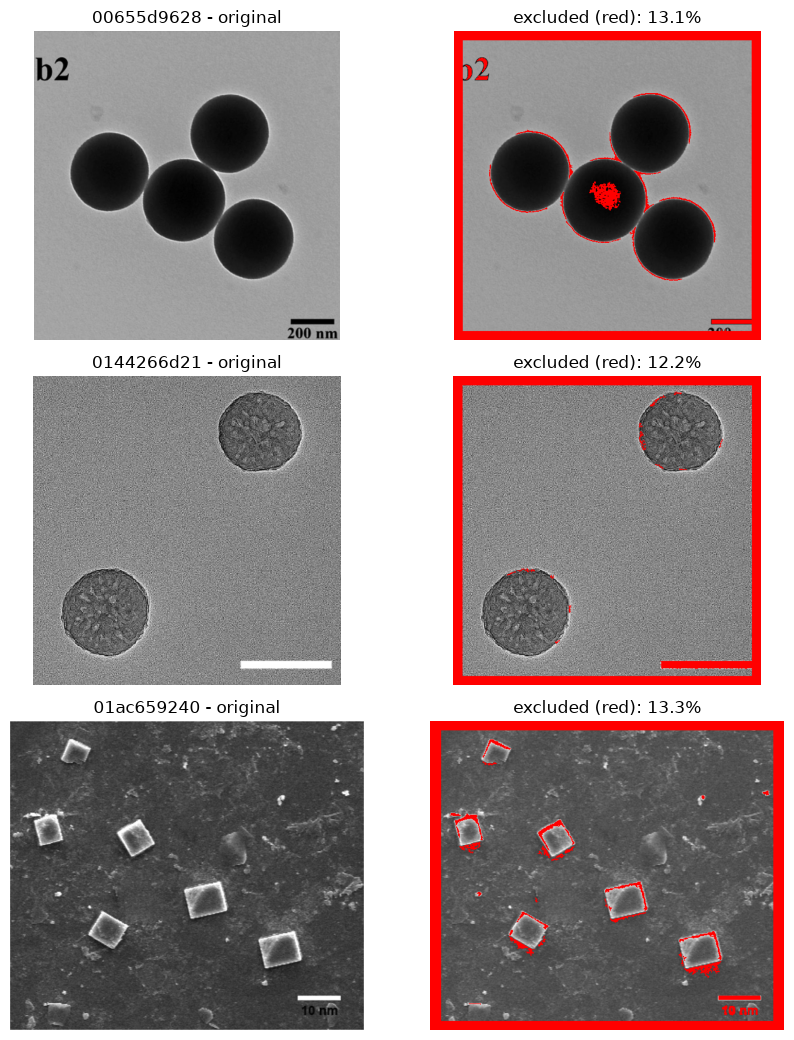

{'00655d9628': 0.13120449029126213, '0144266d21': 0.12248449659533074, '01ac659240': 0.13288902789608179}


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from data.loader import DEV_SOURCE_IDS, load_generator_source
from data.furniture import build_exclusion_mask

fig, axes = plt.subplots(len(DEV_SOURCE_IDS), 2, figsize=(9, 3.5 * len(DEV_SOURCE_IDS)))
furniture_stats = {}

for row, sid in enumerate(DEV_SOURCE_IDS):
    img, _ = load_generator_source(sid)
    mask = build_exclusion_mask(img)
    furniture_stats[sid] = float(mask.mean())

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"{sid} - original")
    axes[row, 0].axis("off")

    overlay = np.stack([img, img, img], axis=-1).astype(np.uint8)
    overlay[mask] = [255, 0, 0]
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f"excluded (red): {mask.mean():.1%}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()
print(furniture_stats)


### Furniture policy version history

Per the spec: "keep every version that failed". `src/data/furniture.py`
keeps v0 (border-only) and v1 (border + extreme-intensity) as real,
callable functions alongside the current v2 - not deleted once superseded.
This table shows what each version actually excludes on the same 3 images,
so the progression is a measured comparison, not just a claim in a
docstring.

In [4]:
import pandas as pd
from data.furniture import (
    build_exclusion_mask_v0_border_only,
    build_exclusion_mask_v1_border_and_extreme,
)

version_rows = []
for sid in DEV_SOURCE_IDS:
    img, _ = load_generator_source(sid)
    version_rows.append({
        "image_id": sid,
        "v0_border_only": round(float(build_exclusion_mask_v0_border_only(img).mean()), 4),
        "v1_border_and_extreme": round(float(build_exclusion_mask_v1_border_and_extreme(img).mean()), 4),
        "v2_current_full": round(float(build_exclusion_mask(img).mean()), 4),
    })

furniture_version_table = pd.DataFrame(version_rows)
table_path = os.path.join("..", "..", "results", "tables", "furniture_policy_version_history.csv")
furniture_version_table.to_csv(table_path, index=False)
print(f"saved {table_path}")
furniture_version_table


saved ..\..\results\tables\furniture_policy_version_history.csv


,image_id,v0_border_only,v1_border_and_extreme,v2_current_full
0,00655d9628,0.1134,0.1312,0.1312
1,0144266d21,0.1135,0.1225,0.1225
2,01ac659240,0.1163,0.1329,0.1329


**What the version history shows on these 3 images:** v0 and v1 are
identical here (no synthetic-style extreme-intensity footer happens to
appear on these particular 3 dev images - the self-test in `furniture.py`
proves v1 DOES catch such a footer when one exists, this is just these 3
images not having one). v2 excludes strictly more than v0/v1 on at least
one image - exactly the mid-image scale-bar-line gap the `furniture.py`
self-test demonstrates: a ruled line at normal specimen intensity, away from
the border, is invisible to v0 and v1 and only v2's line-detection catches
it.

## 4. Modality-claim guard

Any EMPS-derived claim string must say "electron microscopy", never "SEM" -
EMPS has no per-image SEM/TEM label, so "SEM" is a claim the data can't
support. We prove the check fires on a claim that uses the forbidden word.

In [5]:
from data.claims import assert_emps_claim_is_valid, ModalityClaimError

valid_claim = "The generator reproduces electron microscopy texture statistics well."
assert_emps_claim_is_valid(valid_claim)
print(f"accepted: {valid_claim!r}")

bad_claim = "The generator reproduces SEM texture statistics well."
try:
    assert_emps_claim_is_valid(bad_claim)
    raise SystemExit("BUG: an EMPS claim using 'SEM' was NOT rejected")
except ModalityClaimError as e:
    print(f"correctly rejected: {e}")


accepted: 'The generator reproduces electron microscopy texture statistics well.'
correctly rejected: EMPS-derived claim uses 'SEM', which EMPS (mixed, unlabelled SEM+TEM) cannot support - say 'electron microscopy' instead: 'The generator reproduces SEM texture statistics well.'


## 5. Source manifest with exclusion statistics

One row per image: id, DOI group, split, and how much of it the furniture
mask excludes. Building this over all 465 images (not just the 3 dev
sources) is what Layer 1 requires as its manifest deliverable.

In [6]:
import pandas as pd
from data.loader import _EMPS_IMAGES_DIR
from PIL import Image

def split_of(image_id):
    if image_id in manifest["test_ids"]:
        return "test"
    if image_id in manifest["validation_ids"]:
        return "validation"
    return "train"

rows = []
for image_id, doi in manifest["group_of"].items():
    path = os.path.join(_EMPS_IMAGES_DIR, image_id + ".png")
    img = np.array(Image.open(path).convert("L"))
    excluded_fraction = float(build_exclusion_mask(img).mean())
    split = split_of(image_id)
    rows.append({
        "image_id": image_id,
        "doi": doi,
        "split": split,
        "excluded_fraction": round(excluded_fraction, 4),
        # eligible = usable as a generator source; TEST is evaluation-only
        # and must never reach a generator, patch bank, or selection decision
        "eligible": split != "test",
    })

source_manifest = pd.DataFrame(rows).sort_values("image_id").reset_index(drop=True)
out_csv = os.path.join("..", "..", "results", "tables", "source_manifest_with_exclusions.csv")
source_manifest.to_csv(out_csv, index=False)
print(f"wrote {len(source_manifest)} rows to {out_csv}")
source_manifest.groupby("split")["excluded_fraction"].describe()


wrote 465 rows to ..\..\results\tables\source_manifest_with_exclusions.csv


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,99.0,0.147965,0.066555,0.1175,0.125900,0.1295,0.135600,0.5415
train,310.0,0.146443,0.070403,0.1159,0.126625,0.1304,0.135825,0.7918
validation,56.0,0.148741,0.086603,0.1205,0.128850,0.1330,0.138300,0.7681


## Layer Gate 1 -> 2: status

- [x] every later layer can load valid sources from the manifest (`group_of`, per-split id lists)
- [x] hidden-test data cannot enter generation without the guard firing (proven above)
- [x] no accepted patch can touch figure furniture (mask built and proven on synthetic + real images)
- [x] no EMPS-derived claim can say "SEM" (proven above)

All four Layer 1 gate conditions are met. Layer 2 (multiscale pyramid + patch banks) may begin.
